# XGBoost

## Importaciones

In [29]:
import time
import pandas as pd

In [30]:
import warnings
warnings.filterwarnings('ignore')

In [31]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [32]:
from xgboost import XGBClassifier

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [34]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

Cargamos las librerias a utilizar

## Cargado de datos

In [35]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 15), (42539, 15), (170152, 1), (42539, 1))

In [37]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

cargamos los datos

## Funciones usadas

In [38]:
from funciones import *

## Modelo XGBoost

In [39]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
y_train_enc = y_train.map(mapping)
y_test_enc = y_test.map(mapping)
labels = list(mapping.values())              
target_names = list(mapping.keys())  

In [40]:
pipe_XGBoost=crear_pipeline(XGBClassifier(
    objective="multi:softprob",  
    num_class=3,                 
    eval_metric="mlogloss",       
    random_state=0
), tipo="normal")

In [41]:
start = time.time()
model_pipe = pipe_XGBoost.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.04 minutos


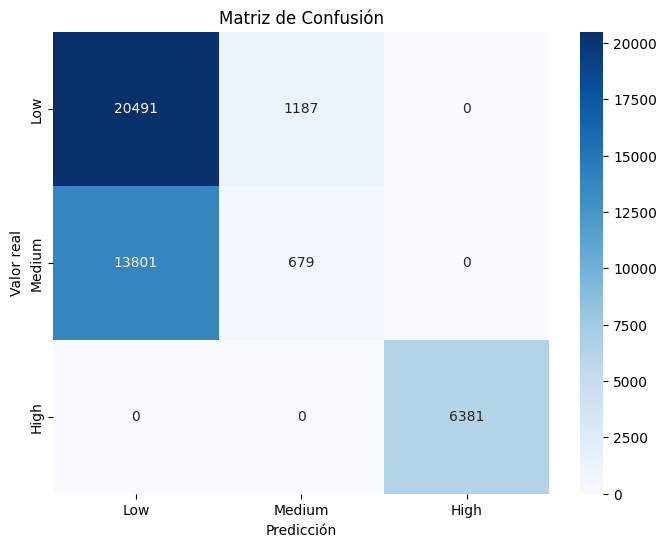


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.95      0.73     21678
      Medium       0.36      0.05      0.08     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.65     42539
   macro avg       0.65      0.66      0.61     42539
weighted avg       0.58      0.65      0.55     42539



{'Accuracy': 0.6476644961094525,
 'Precision (macro)': 0.6538081913159317,
 'Recall (macro)': 0.6640454304650164,
 'F1-score (macro)': 0.6050973716255372,
 'ROC-AUC': 0.7550632207255386}

In [42]:
evaluar_modelo(model_pipe, X_test, y_test_enc, class_map=mapping)

En general se puede observar que hay un desbalance muy grande en el modelo, medium tiene muy bajos scores de recall y F1, y High tiene todos su scores en 1, lo que se debe tomar en cuenta, talvez se deba al desbalance

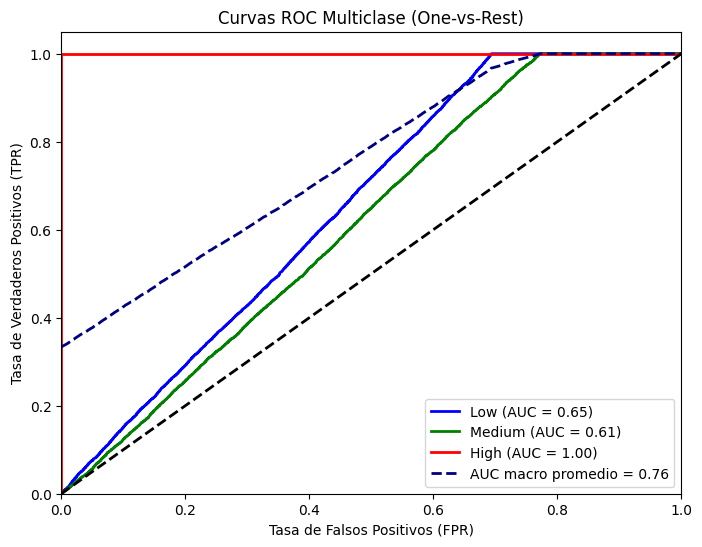

In [43]:
plot_roc_multiclass2(model_pipe, X_test, y_test)

## Balance de modelo

### SMOTE

In [44]:
pipe_XGBoost_bal=crear_pipeline(XGBClassifier(
    objective="multi:softprob",  
    num_class=3,                 
    eval_metric="mlogloss",       
    random_state=0
), tipo="balanceo_smote",y_train=y_train_enc)

In [45]:
start = time.time()
model_pipe_bal = pipe_XGBoost_bal.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.25 minutos


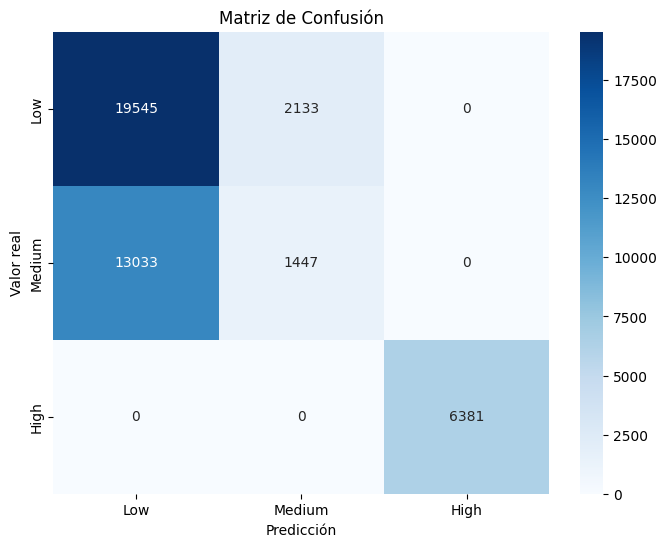


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.90      0.72     21678
      Medium       0.40      0.10      0.16     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.64     42539
   macro avg       0.67      0.67      0.63     42539
weighted avg       0.59      0.64      0.57     42539



{'Accuracy': 0.6434801006135547,
 'Precision (macro)': 0.6680448973745063,
 'Recall (macro)': 0.6671787511232968,
 'F1-score (macro)': 0.6269056480147055,
 'ROC-AUC': 0.7566235243622073}

In [46]:
evaluar_modelo(model_pipe_bal, X_test, y_test_enc, class_map=mapping)

Podemos observar que incluso luego del balanceo por SMOTE, Medium tiene valores bajos en recall y F1, aunque si es una mejora en comparacion con el modelo benchmark no balanceado

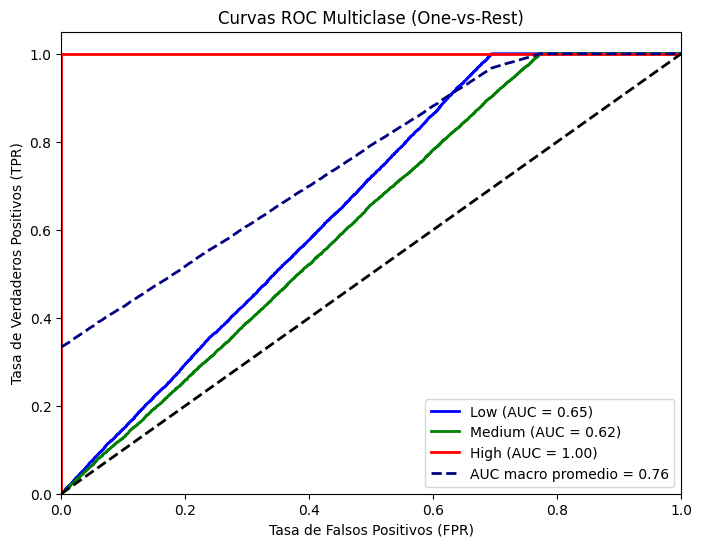

In [47]:
plot_roc_multiclass2(model_pipe_bal, X_test, y_test)

### ADASYN

In [48]:
pipe_XGBoost_ads=crear_pipeline(XGBClassifier(
    objective="multi:softprob",  
    num_class=3,                 
    eval_metric="mlogloss",       
    random_state=0
), tipo="balanceo_adasyn",y_train=y_train_enc)

In [49]:
start = time.time()
model_pipe_ads = pipe_XGBoost_ads.fit(X_train,y_train_enc)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.48 minutos


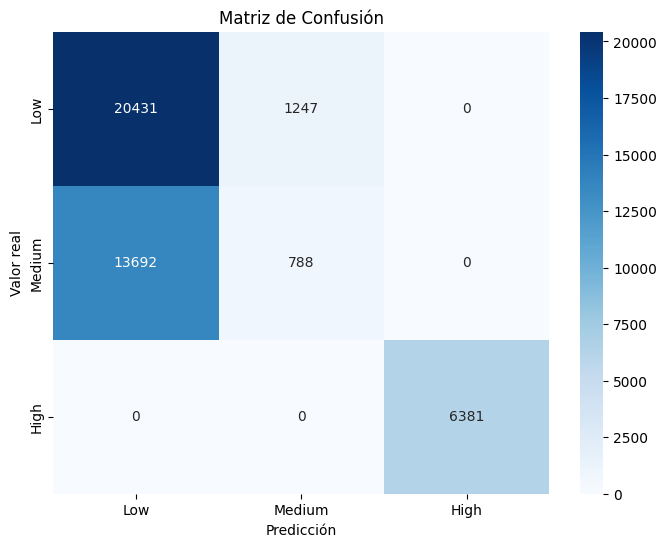


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.94      0.73     21678
      Medium       0.39      0.05      0.10     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.65     42539
   macro avg       0.66      0.67      0.61     42539
weighted avg       0.59      0.65      0.56     42539



{'Accuracy': 0.6488163802628176,
 'Precision (macro)': 0.6619897670860365,
 'Recall (macro)': 0.6656320442328764,
 'F1-score (macro)': 0.6092363939747257,
 'ROC-AUC': 0.7556133000120336}

In [50]:
evaluar_modelo(model_pipe_ads, X_test, y_test_enc, class_map=mapping)

El balanceo por ADASYN no ayudo a la mejora del modelo, con scores casi iguales no se observa una mejora significativa en comparacion al original  

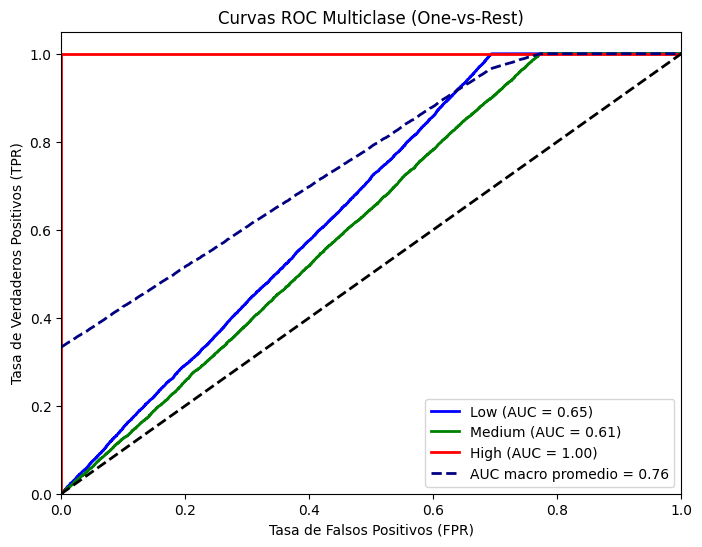

In [51]:
plot_roc_multiclass2(model_pipe_ads, X_test, y_test)

## Optimizacion computacional

In [52]:
pipe_XGBoost_opt = crear_pipeline(
    XGBClassifier(
        objective="multi:softprob",   # Clasificación multiclase
        num_class=3,                  # Número de clases
        eval_metric="mlogloss",       # Métrica multiclase
        tree_method="hist",           # Entrenamiento rápido
        random_state=0
    ),
    tipo="balanceo_smote",
    y_train=y_train_enc
)

In [53]:
start = time.time()
model_pipe_opt = pipe_XGBoost_opt.fit(
    X_train,
    y_train_enc,
)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.26 minutos


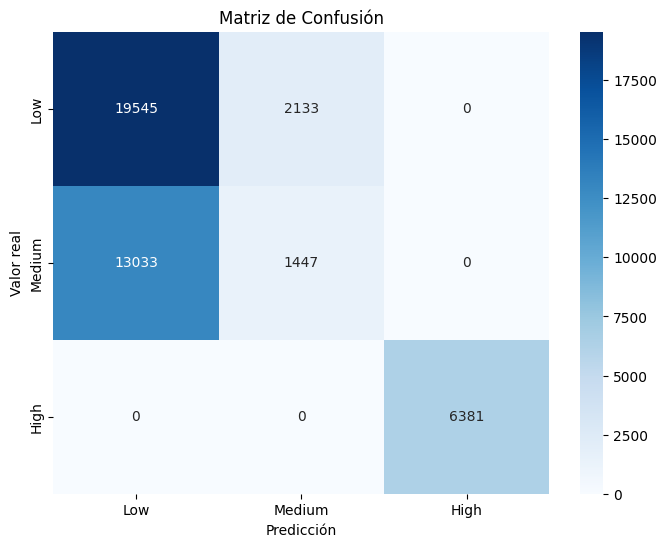


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.90      0.72     21678
      Medium       0.40      0.10      0.16     14480
        High       1.00      1.00      1.00      6381

    accuracy                           0.64     42539
   macro avg       0.67      0.67      0.63     42539
weighted avg       0.59      0.64      0.57     42539



{'Accuracy': 0.6434801006135547,
 'Precision (macro)': 0.6680448973745063,
 'Recall (macro)': 0.6671787511232968,
 'F1-score (macro)': 0.6269056480147055,
 'ROC-AUC': 0.7566235243622073}

In [54]:
evaluar_modelo(model_pipe_opt, X_test, y_test_enc, class_map=mapping)


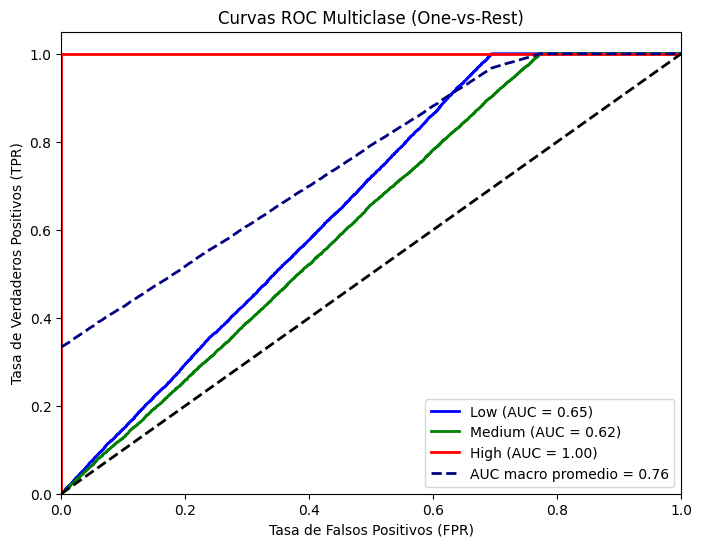

In [55]:
plot_roc_multiclass2(model_pipe_opt, X_test, y_test)

## Tabla comparativa

| XGBoost    | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.65     | 0.65     | 0.66   | 0.61    | 0.76 | 0.07
| SMOTE     | 0.64     | 0.67     | 0.67   | 0.63     | 0.76 | 0.22
| ADASYN     | 0.65    | 0.66     | 0.67   | 0.61     | 0.76 |0.37
| Optimizacion | 0.64  | 0.67     | 0.67   | 0.63    | 0.76 | 0.17

## Lime 

In [56]:

from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

pipes = {
    "normal": pipe_XGBoost,
    "smote": pipe_XGBoost_bal,
    "adasyn": pipe_XGBoost_ads
}

if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

fila = 0 

def separar_transformador_y_modelo(pipe):
    if not isinstance(pipe, Pipeline):
        raise ValueError("El objeto no es un Pipeline.")

    transformadores = []
    for name, step in pipe.steps:
        if hasattr(step, "transform") or hasattr(step, "fit_transform"):
            transformadores.append((name, step))
        else:
            break
    preprocessor = Pipeline(transformadores) if transformadores else None

    for name, step in reversed(pipe.steps):
        if hasattr(step, "predict_proba"):
            return preprocessor, step
    raise ValueError("No se encontró clasificador con predict_proba en el pipeline.")

for nombre, modelo in pipes.items():
    print(f"\n--- Generando LIME para modelo: {nombre.upper()} ---")

    preprocessor, classifier = separar_transformador_y_modelo(modelo)

    if preprocessor is not None:
        X_train_trans = preprocessor.transform(X_train)
        X_test_trans = preprocessor.transform(X_test)
        try:
            feature_names = preprocessor.get_feature_names_out()
        except Exception:
            feature_names = [f"f_{i}" for i in range(X_train_trans.shape[1])]
    else:
        X_train_trans = X_train.values
        X_test_trans = X_test.values
        feature_names = X_train.columns.tolist()

    explainer = LimeTabularExplainer(
        training_data=np.array(X_train_trans),
        feature_names=feature_names,
        class_names=[str(c) for c in np.unique(y_train)],
        mode="classification",
        discretize_continuous=True
    )

    def pred_fn(x):
        return classifier.predict_proba(x)
    
    exp = explainer.explain_instance(
        data_row=X_test_trans[fila],
        predict_fn=pred_fn
    )

    exp.show_in_notebook(show_table=True, show_all=False)
    exp.save_to_file(f"lime_{nombre}.html")





--- Generando LIME para modelo: NORMAL ---



--- Generando LIME para modelo: SMOTE ---



--- Generando LIME para modelo: ADASYN ---


## modelo normal



El gráfico muestra la explicación local del modelo XGBoost para una observación clasificada como **"NOT Low"** (riesgo no bajo).  
El modelo asigna una probabilidad del **61 % para riesgo alto** y **39 % para riesgo bajo**.  
Las variables que más influyeron hacia la clase *Low* fueron `Radiation_Exposure_Yes`, `Country_India` y `Family_History_Yes`.  
Sin embargo, factores como `Ethnicity_Asian`, `Iodine_Deficiency_Yes` y `Ethnicity_Caucasian` impulsaron la predicción hacia un riesgo mayor, inclinando el resultado final hacia **riesgo alto**.  
Esto evidencia que las características étnicas y nutricionales tienen una contribución relevante en la decisión del modelo.


## modelo Smote

En esta explicación local, el modelo XGBoost presenta una predicción **equilibrada** entre las clases *High* (53 %) y *Low* (47 %).  
Las variables con mayor influencia hacia la clase **Low** fueron `Radiation_Exposure_Yes`, `Family_History_Yes` y `Country_India`, sugiriendo que estos factores reducen el riesgo estimado.  
Por otro lado, características como `Ethnicity_Asian` y `Iodine_Deficiency_Yes` aportaron mayor peso hacia la clase **High**, indicando que el modelo las asocia con un mayor riesgo de cáncer de tiroides.  
En conjunto, el modelo muestra una decisión borderline, donde pequeñas variaciones en los factores podrían cambiar la clasificación final.


## modelo ADASYN

En este caso, el modelo ADASYN muestra una predicción **muy equilibrada** entre las clases *High* (53 %) y *Low* (47 %), indicando incertidumbre en la clasificación.  
Las variables que impulsaron la predicción hacia **Low** fueron `Radiation_Exposure_Yes`, `Family_History_Yes` y `Country_India`.  
Por el contrario, las características `Ethnicity_Asian`, `Iodine_Deficiency_Yes` y `Country_Germany` favorecieron la clase **High**, siendo las principales responsables de mantener el riesgo alto.  
Este resultado sugiere que el modelo ADASYN, al manejar mejor el desbalance de clases, logra una decisión más estable pero aún sensible a factores étnicos y de deficiencia de yodo.